# LoraE Results and Visualization
This notebook provides a comprehensive view of the LoraE model performance across various scenarios and adaptive behaviors.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Paths
model_name = 'LoraF_invi_visi_rank_1'
model_dir = f'trained_models/{model_name}/test/'
video_root = 'visualizations'
master_csv = 'result/master_summary.csv'
current_exp_id = '1' # Set to your exp_id (e.g. '1') or None for default
show_videos = False # Set to False to disable video rendering and speed up the notebook

scenarios = [
    'all_ignorant',
    'all_aware',
    'ignorant_to_aware_step25',
    'mixed_5050'
]

def load_results(scenarios, behaviors, exp_id=None):
    results = []
    exp_suffix = f"_exp{exp_id}" if exp_id else ""
    for scenario in scenarios:
        for behavior in behaviors:
            filename = f"seperate_{scenario}_{behavior}{exp_suffix}.json"
            filepath = os.path.join(model_dir, filename)
            
            if os.path.exists(filepath):
                with open(filepath, 'r') as f:
                    data = json.load(f)
                summary = data.get('summary', {})
                if summary.get('num_episodes', 0) >= 500:
                    res = {
                        'Scenario': scenario,
                        'Behavior': behavior,
                        'SR': summary.get('success_rate'),
                        'CR': summary.get('collision_rate'),
                        'TR': summary.get('timeout_rate'),
                        'NavTime': summary.get('avg_nav_time'),
                        'PathLen': summary.get('avg_path_length'),
                        'Uncertainty': summary.get('avg_uncertainty'),
                        'AvgLoRA': summary.get('avg_lora_scale', 'N/A'),
                        'TP': summary.get('tp', 'N/A'),
                        'TN': summary.get('tn', 'N/A'),
                        'FP': summary.get('fp', 'N/A'),
                        'FN': summary.get('fn', 'N/A'),
                        'Friendly': summary.get('avg_discrepancy_aware', 'N/A'),
                        'Ignorant': summary.get('avg_discrepancy_ignorant', 'N/A'),
                        'All': summary.get('avg_discrepancy_all', 'N/A')
                    }
                    results.append(res)
            else:
                print(f"File not found: {filepath}")
    return pd.DataFrame(results)

def generate_video_grid(scenarios, behaviors, exp_id=None):
    exp_suffix = f"_exp{exp_id}" if exp_id else ""
    html_code = "<div style='display: grid; grid-template-columns: repeat({n_cols}, 1fr); gap: 10px; text-align: center;'>".format(n_cols=len(behaviors)+1)
    html_code += "<div style='background: #eee;'>Scenario \\ Behavior</div>"
    for b in behaviors:
        html_code += f"<div style='font-weight: bold; background: #eee;'>{b}</div>"

    for s in scenarios:
        html_code += f"<div style='font-weight: bold; display: flex; align-items: center; justify-content: center; background: #fafafa;'>{s}</div>"
        for b in behaviors:
            video_found = False
            # Try Success then Collision
            for status in ['Success', 'Collision']:
                video_filename = f"seperate_{s}_{b}{exp_suffix}_ep0_{status}.mp4"
                video_path = os.path.join(video_root, model_name, f"seperate_{s}", video_filename)
                if os.path.exists(video_path):
                    html_code += f"<div><video width='100%' controls><source src='{video_path}' type='video/mp4'></video></div>"
                    video_found = True
                    break
            if not video_found:
                html_code += "<div style='border: 1px solid #ccc; height: 100px; display: flex; align-items: center; justify-content: center;'>Video Missing</div>"
    html_code += "</div>"
    return HTML(html_code)

## 1. Performance with Ground Truth Knowledge
This section compares the baseline behaviors with ground-truth switching and adaptive logic.

In [2]:
gt_behaviors = ['always_off', 'always_on', 'switching_gt', 'adaptive_gt']
df_gt = load_results(scenarios, gt_behaviors, exp_id=current_exp_id)

print("### Results Table (Ground Truth Knowledge)")
display(df_gt)

if show_videos:
    print("\n### Video Grid (Ground Truth Knowledge)")
    display(generate_video_grid(scenarios, gt_behaviors, exp_id=current_exp_id))

### Results Table (Ground Truth Knowledge)


,Scenario,Behavior,SR,CR,TR,NavTime,PathLen,Uncertainty,AvgLoRA,TP,TN,FP,FN,Friendly,Ignorant,All
0,all_ignorant,always_off,0.896,0.084,0.020,19.448661,26.551582,0.089426,0.000000,0,0,0,0,0.000000,0.724194,0.724194
1,all_ignorant,always_on,0.432,0.568,0.000,12.699074,16.881205,0.132224,1.000000,0,0,0,0,0.000000,0.177613,0.177613
2,all_ignorant,switching_gt,0.896,0.084,0.020,19.448661,26.551582,0.089426,0.000000,0,0,0,0,0.000000,0.724194,0.724194
3,all_ignorant,adaptive_gt,0.896,0.084,0.020,19.448661,26.551582,0.089426,0.000000,0,0,0,0,0.000000,0.724194,0.724194
4,all_aware,always_off,0.996,0.000,0.004,18.770080,26.326727,0.093761,0.000000,0,0,0,0,0.667841,0.000000,0.667841
5,all_aware,always_on,0.984,0.016,0.000,11.359756,18.741230,0.137099,1.000000,0,0,0,0,0.163917,0.000000,0.163917
6,all_aware,switching_gt,0.984,0.016,0.000,11.358740,18.740728,0.137130,0.995590,0,0,0,0,0.164382,0.000000,0.164382
7,all_aware,adaptive_gt,0.984,0.016,0.000,11.358740,18.740728,0.137130,0.995590,0,0,0,0,0.164382,0.000000,0.164382
8,ignorant_to_aware_step25,always_off,0.960,0.036,0.004,19.317708,26.392797,0.091309,0.000000,0,0,0,0,0.800789,0.185536,0.684807
9,ignorant_to_aware_step25,always_on,0.856,0.144,0.000,12.637850,18.889158,0.136048,1.000000,0,0,0,0,0.214736,0.098302,0.175022


## 2. Performance vs LoRA Scale (Sweep)
This plot shows how fixed LoRA scales impact Success and Collision rates.

Skipping scale 1.0: Only 1 episodes (min_episodes=50)


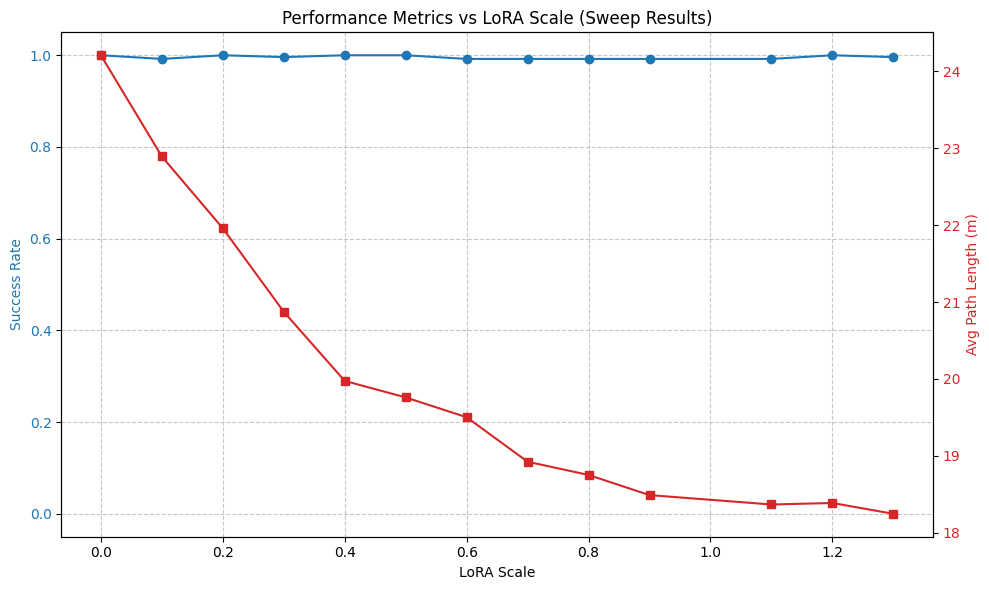

,lora_scale,success_rate,avg_path_length,total_episodes
8,0.0,1.000,24.206217,500
10,0.1,0.992,22.890723,500
2,0.2,1.000,21.957726,500
3,0.3,0.996,20.873358,500
4,0.4,1.000,19.974664,500
11,0.5,1.000,19.760091,500
5,0.6,0.992,19.502626,500
0,0.7,0.992,18.924640,500
7,0.8,0.992,18.752558,500
1,0.9,0.992,18.490772,500


In [3]:
import glob
import re

# Settings
min_episodes = 50

# Find all scale-specific CSV files in the test directory
csv_files = glob.glob(os.path.join(model_dir, 'evaluation_data_scale_*.csv'))
results = []

for csv_path in csv_files:
    match = re.search(r'evaluation_data_scale_([\d\.]+)\.csv', os.path.basename(csv_path))
    if match:
        scale = float(match.group(1))
        df = pd.read_csv(csv_path)
        
        # Calculate counts accurately (matching plot_lora_results.py)
        successes = df['Success Times'].count()
        collisions = df['Collision Times'].count()
        timeouts = df['Timeout Times'].count()
        total = successes + collisions + timeouts
        
        if total < min_episodes:
            print(f"Skipping scale {scale}: Only {total} episodes (min_episodes={min_episodes})")
            continue

        results.append({
            'lora_scale': scale,
            'success_rate': successes / total,
            'avg_path_length': df['Path Length'].mean(),
            'total_episodes': total
        })

if results:
    df_sweep = pd.DataFrame(results).sort_values(by='lora_scale')
    
    # Prepare lists for dual-axis plotting (matching plot_lora_results.py style)
    scales = df_sweep['lora_scale'].tolist()
    sr = df_sweep['success_rate'].tolist()
    pl = df_sweep['avg_path_length'].tolist()
    
    # Dual axis plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel('LoRA Scale')
    ax1.set_ylabel('Success Rate', color=color)
    ax1.plot(scales, sr, 'o-', color=color, label='Success Rate')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Avg Path Length (m)', color=color)
    ax2.plot(scales, pl, 's-', color=color, label='Avg Path Length')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Performance Metrics vs LoRA Scale (Sweep Results)')
    fig.tight_layout()
    plt.show()
    
    display(df_sweep[['lora_scale', 'success_rate', 'avg_path_length', 'total_episodes']])
else:
    print("No valid scale-specific CSV data found in ", model_dir)

## 3. Comparison: GT vs Discrepancy (Estimated Knowledge)
Comparing performance when using Ground Truth vs Discrepancy-based estimation for Switching and Adaptive behaviors.

In [4]:
comp_behaviors = ['switching_gt', 'switching_discrepancy', 'switching_discrepancynew', 'adaptive_gt', 'adaptive_discrepancy', 'adaptive_discrepancynew']
df_comp = load_results(scenarios, comp_behaviors, exp_id=current_exp_id)

print("### Comparison Table (GT vs Discrepancy)")
display(df_comp)

if show_videos:
    print("\n### Comparison Video Grid (GT vs Discrepancy)")
    display(generate_video_grid(scenarios, comp_behaviors, exp_id=current_exp_id))

File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_switching_discrepancynew_exp1.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_adaptive_discrepancynew_exp1.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_aware_switching_discrepancynew_exp1.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_aware_adaptive_discrepancynew_exp1.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_ignorant_to_aware_step25_switching_discrepancynew_exp1.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_ignorant_to_aware_step25_adaptive_discrepancynew_exp1.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_mixed_5050_switching_discrepancynew_exp1.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_mixed_5050_adaptive_discrepancynew_exp1.json
### Comparison Table (GT vs Discrepancy)


,Scenario,Behavior,SR,CR,TR,NavTime,PathLen,Uncertainty,AvgLoRA,TP,TN,FP,FN,Friendly,Ignorant,All
0,all_ignorant,switching_gt,0.896,0.084,0.020,19.448661,26.551582,0.089426,0.000000,0,0,0,0,0.000000,0.724194,0.724194
1,all_ignorant,switching_discrepancy,0.756,0.244,0.000,19.751323,23.816589,0.098089,0.186471,0,260408,67980,0,0.000000,0.649255,0.649255
2,all_ignorant,adaptive_gt,0.896,0.084,0.020,19.448661,26.551582,0.089426,0.000000,0,0,0,0,0.000000,0.724194,0.724194
3,all_ignorant,adaptive_discrepancy,0.768,0.216,0.016,18.617188,24.124966,0.105143,0.221623,0,297036,67674,0,0.000000,0.561872,0.561872
4,all_aware,switching_gt,0.984,0.016,0.000,11.358740,18.740728,0.137130,0.995590,0,0,0,0,0.164382,0.000000,0.164382
5,all_aware,switching_discrepancy,0.988,0.008,0.004,19.526316,26.912813,0.103983,0.119308,82504,0,0,321896,0.643987,0.000000,0.643987
6,all_aware,adaptive_gt,0.984,0.016,0.000,11.358740,18.740728,0.137130,0.995590,0,0,0,0,0.164382,0.000000,0.164382
7,all_aware,adaptive_discrepancy,0.996,0.000,0.004,18.893574,26.364336,0.115694,0.194301,81462,0,0,377546,0.551808,0.000000,0.551808
8,ignorant_to_aware_step25,switching_gt,0.948,0.052,0.000,16.017932,22.886539,0.111174,0.581103,0,0,0,0,0.390880,0.185536,0.344312
9,ignorant_to_aware_step25,switching_discrepancy,0.848,0.152,0.000,19.448113,24.413618,0.098879,0.174753,31184,52818,38272,218064,0.743621,0.147840,0.625090
